In [9]:
# 라이브러리 설치
# pip install langchain-openai langchain-core langgraph langchain-chroma rank_bm25

import os
import logging
from dotenv import load_dotenv
import pandas as pd
from typing import Literal, TypedDict, List
from pydantic import BaseModel, Field
from langchain_openai import ChatOpenAI
from langchain.schema import Document
from langchain_community.retrievers import BM25Retriever
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableConfig, RunnableLambda
from langchain.retrievers import EnsembleRetriever
from langgraph.graph import StateGraph, START, END

In [2]:
# 환경 변수 로드 및 로깅 설정
load_dotenv()
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(name)s - %(levelname)s - %(message)s')

In [3]:
#----1. 모델 정의----
model = ChatOpenAI(
    model_name='gpt-4o-mini',
    temperature=0 #같은 답 무조건
)

In [4]:
#----2. State 정의----

from langchain_core.runnables import RunnableLambda
from typing_extensions import TypedDict
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.output_parsers import StrOutputParser

#그래프 각 노드 간에 데이터를 전달하기 위한 상태 정의
class State(TypedDict):
    input_msg: str
    generation: str
    documents: List[str]
    source: str

In [5]:
#----3. RAG 설정 (미리 로드)----
from langchain_chroma import Chroma
from langchain_openai import AzureOpenAIEmbeddings
from langchain_community.retrievers import BM25Retriever #키워드 검색할 수 있도록 하는 친구
from langchain.retrievers import EnsembleRetriever
from langchain.tools.retriever import create_retriever_tool

#문서 설정
docs = []

file_path = os.path.join('data', 'GodQuestions1.xlsx')
df = pd.read_excel(file_path)

# DataFrame의 각 행을 반복하면서 Document 객체 생성
for index, row in df.iterrows():
    # page_content: RAG가 직접 참조할 텍스트 (질문과 답변을 합침)
    content = f"질문: {row['Question_KOR']}\n\n답변: {row['Answer_KOR']}"
    
    # metadata: 문서의 출처, 카테고리 등 부가 정보
    metadata = {
        "source": row['URL_KOR'],
        "category": row['big_title_kor'],
        "row_number": index + 1
    }
    
    # Document 객체 생성하여 리스트에 추가
    docs.append(Document(page_content=content, metadata=metadata))


In [8]:
#Embedding
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

'''
#Chroma 벡터 저장소 생성하기 (초기)
chroma_db = Chroma.from_documents(
    documents=docs,
    embedding=embeddings,
    persist_directory="./chroma_db",
)
'''
#Chroma DB 로드
chroma_db = Chroma(
    embedding_function=embeddings,
    persist_directory="./chroma_db",
)

#Retriever 생성
chroma_retriever = chroma_db.as_retriever(search_kwargs={"k": 2}) #근접한 결과 2개 리턴 # Semantic 검색기
bm25_retriever = BM25Retriever.from_documents(docs) # BM25 검색기 생성
ensemble_retriever = EnsembleRetriever(
    retrievers=[chroma_retriever, bm25_retriever],
    weights=[0.5, 0.5] #각 검색기마다의 가중치 - 지금은 반반 가져오겠다는 의미, 데이터에 따라 가중치 미세조정 필요하다
)

In [24]:
#----4. 노드 및 체인 정의----
#Router - 주제 분류 체인
def router(state): #주제 분류 노드 - 빈 노드
    return state

class RouteQuery(BaseModel):
    """
    Route a user query to the most relevant role.
    """
    
    router : Literal["block", "rag", "default"] = Field(
        description = "Given a user question choose to route it th block, rag or default."
    )

#conditional edge
def route_query(input_msg) -> Literal["block", "rag", "default"]:
    model_with_structured_output = model.with_structured_output(RouteQuery)
    
    system = """
    You are an expert at routing/classifying a user question to block, rag or dafault.
    
    Classification Criteria:
    1. block: Profanity, curses, spam, advertising, inappropriate sexual content, threatening messages
    2. default: General concerns, life problems, relationships, stress, depression, etc.
    3. rag: Faith-related questions, religious concerns, spiritual issues, questions about the Bible
    
    You must answer only one of these three words.
    """
    
    prompt_router = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "{input_msg}"),
        ]
    )
    
    chain_router = prompt_router | model_with_structured_output
    
    out = chain_router.invoke(
        {
            "input_msg": input_msg
        }
    )
    
    if out.router == "block":
        print(">> ROUTE QUESTION TO BLOCK")
        return "block"
    elif out.router == "rag":
        print(">> ROUTE QUESTION TO RAG")
        return "rag"
    elif out.router == "default":
        print(">> ROUTE QUESTION TO DEFAULT")
        return "default"

In [25]:
#Dafault 질문 답변 노드 생성
def node_default_responser(state: State) -> State:
    """'Default' 주제에 대한 일반적인 답변 생성"""
    print(">> DEFAULT")
    input_msg = state["input_msg"]
    
    system = """
    You are a You are a Christian counselor AI, created to share the love of Jesus through gentle, compassionate conversation. 
    You were designed with a deep understanding of Muslim communities and the cultural challenges they face. 
    Never rush faith — let love lead the way Always return to the hope, healing, and dignity we have in Christ.
    """
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", system),
    ])
    
    chain = prompt | model | StrOutputParser()
    
    result = chain.invoke(
        {"input_msg": state["input_msg"]}
    )
    
    return {
        "input_msg": input_msg,
        "source": "default",
        "generation": result
    }
    
    
#RAG 노드 생성
def node_rag_responser(state: State) -> State:
    """'Gospel' 주제에 대해 RAG를 사용하여 답변 생성"""
    
    print(">> RETRIEVE")
    input_msg = state["input_msg"]
    
    documents = ensemble_retriever.invoke(input_msg)
    
    return {
        "documents": documents,
        "input_msg": input_msg,
        "source": "vectorstore"
    }
     

#Block 노드 생성
def node_block_responser(state: State) -> State:
    """'Block' 주제에 대해 응답하지 않도록 설정"""
    print(">> BLOCK")
    
    prompt = ChatPromptTemplate.from_template(
        """
        Do not respond to cursing, profanity, spam, advertising, inappropriate sexual content, or threatening messages.
        Don't say anything.
        """
    
    )
    return {
        "generate": prompt
    }


In [26]:
#Rewrite Query
def rewrite_query(state):
    print(">> REWRITE QUERY")
    input_msg = state["input_msg"]
    documents = state["documents"]
    
    system = """
    You are a question re-writer that converts an input question to a better version that is optimized
    for vectorstore retrieval. Look at the input and try to reason about the underlying semantic intent.
    """
    
    prompt_rewriter = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "Here is the initial question: \n\n {question}.")
        ]
    )

    chain_rewriter = prompt_rewriter | model | StrOutputParser()
    
    new_question = chain_rewriter.invoke(
        {
            "input_msg": input_msg
        }
    )
    
    return {
        "documents": documents,
        "input_msg": new_question
    }

In [34]:
#RAG 답변 Generate
from langchain import hub
from langchain_core.output_parsers import StrOutputParser

def generate(state):
    print(">> GENERATE")
    input_msg = state["input_msg"]
    documents = state["documents"]
    source = state["source"]
    
    system = """ 
    You are a wise and compassionate pastor with deep knowledge of the Bible and Christian faith.
    You provide spiritual guidance and counsel based on biblical principles.

    Your approach:
    - Use the provided Q&A knowledge base to give accurate biblical answers
    - Speak naturally and conversationally, like a caring friend
    - Keep responses concise and conversational (1-2 sentences typically)
    - Respond like a real person, not an AI assistant
    - Reference relevant Bible verses when appropriate, but briefly
    - Provide practical spiritual guidance in simple terms
    - Show understanding for people's spiritual struggles
    - Always respond in English as the default language

    When someone asks about faith, doctrine, or spiritual matters:
    1. Draw from the provided knowledge base for accurate information
    2. Give brief, human-like responses that feel personal
    3. Share biblical wisdom naturally, as if in conversation
    4. Offer simple, practical encouragement
    5. Avoid overly formal or lengthy explanations
    """
    
    prompt = ChatPromptTemplate.from_messages([
        ("system", system),
        ("human", input_msg)
    ])
    
    chain_rag = prompt | model | StrOutputParser()
    
    out = chain_rag.invoke(
        {
            "context": documents,
            "input_msg": input_msg
        }
    )
    
    return {
        "documents": documents,
        "input_msg": input_msg,
        "source": source,
        "generation": out
    }

In [35]:
#Judge Retrieval
class Relevancy(BaseModel):
    """
    Binary score for relevance check on retrieved documents.
    """
    
    binary_score: str = Field(
        description="Documents are relevant to the question, 'yes' or 'no'"
    )

def judge_retrieval(state):
    print(">> JUDGE RELEVANCE OF THE RETRIEVED DOCUMENTS")
    input_msg = state["input_msg"]
    documents = state["documents"]
    
    model_with_structured_output = model.with_structured_output(Relevancy)
    
    system = """
    You are a judge assessing relevance of a retrieved document to a user input_msg.
    If the document contains keyword(s) or semantic meaning related to the user questio, grade it as 
    It does not need to be a stringent test. The goal is to filter out erroneous retrievals.
    Give a binary score 'yes' or 'no' score to indicate whether the document is relevant to the question.
    """
    
    prompt_retrieval_judge = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "Retrieved document: \n\n {document} \n\n User question: {input_msg}")
        ]
    )
    
    chain_grade = prompt_retrieval_judge | model_with_structured_output
    
    #keep only relevant docs
    filtered_docs = []
    for doc in documents:
        out = chain_grade.invoke(
            {
                "input_msg": input_msg,
                "document": doc.page_content
            }
        )
        
        if out.binary_score == "yes":
            print("    >> DECISION: DOCUMENT RELEVANT")
            filtered_docs.append(doc)
        else:
            print("    >> DECISION: DOCUMENT IRRELEVANT")
    
    return {
        "documents": filtered_docs, #relevant한 친구들만 넘겨줌
        "input_msg": input_msg
    }   

In [36]:
# Judge Hallucination + Answer
#-> Factful? No hallucination?
#-> Answers the question?

class Factfulness(BaseModel):
    """
    Binary score for hallucination present in generation answer.
    """
    
    binary_score: str = Field(
        description="Answer is grounded in the facts, 'yes' or 'no'"
    )
    
class Addressed(BaseModel):
    """
    Binary score to assess answer addresses question.
    """
    
    binary_score: str = Field(
        dsecription="Answer addresses the question, 'yes' or 'no'"
    )
    
def judge_answer(state):
    print(">> CHECK IF ANSWER ADDRESSES/RESOLVES T?HE QUESTION")
    input_msg = state["input_msg"]
    documents = state["documents"]
    generation = state["generation"]
    
    system = """
    You are a grader assessing whether an answer addresses / resolves a question.
    Give a binary score 'yes' or 'no'. 'Yes' means that the answer resolves the question.
    """
    
    prompt_answer_judge = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "User question: \n\n {input_msg} \n\n LLM generation: {generation}")
        ]
    )
    
    model_with_structured_output = model.with_structured_output(Addressed)

    chain_answer = prompt_answer_judge | model_with_structured_output
    
    out = chain_answer.invoke(
        {
            "input_msg": input_msg,
            "generation": generation
        }
    )
    
    print(f"     >> DECISION: {out.binary_score.upper()}")
    
    return out.binary_score

def judge_factfullness(state) -> Literal["resolved", "not resolved", "hallucinating"]:
    print(">> CHECK HALLUCINATION")
    input_msg = state["input_msg"]
    documents = state["documents"]
    generation = state["generation"]
    
    system = """
    You are a judge assessing whether an LLM generation is grounded in / supported by a set of retrieve
    Give a binary score 'yes' or 'no'. 'Yes' means that the answer is grounded in // supported by the
    """
    
    prompt_hallucination_judge = ChatPromptTemplate.from_messages(
        [
            ("system", system),
            ("human", "Set of facts: \n\n {documents} \n\n LLM generation: {generation}")
        ]
    )
    
    model_with_structured_output = model.with_structured_output(Addressed)
    
    chain_hallucination = prompt_hallucination_judge | model_with_structured_output
    
    out = chain_hallucination.invoke(
        {
            "documents": documents,
            "generation": generation
        }
    )
    
    if out.binary_score == "yes":
        print("    >> DECISION: FACTFUL")
        
        is_answering = judge_answer(state)
        if is_answering == "yes":
            return "resolved"
        else:
            return "not resolved"
    else:
        print("    >> DECISION: HALLUCINATING")
        return "hallucinating"

In [37]:
#Generate or Rewrite Query?
def generate_or_rewrite_query(state) -> Literal["generate", "rewrite_query"]:
    print(">> HAS RELEVANT DOCS?")
    state["input_msg"]
    filtered_docs = state["documents"]
    
    if len(filtered_docs) > 0:
        print("    >> DECISION: GENERATE")
        return "generate"
    else: 
        print("    >> DECISION: REWRITE QUERY")
        return "rewrite_query"

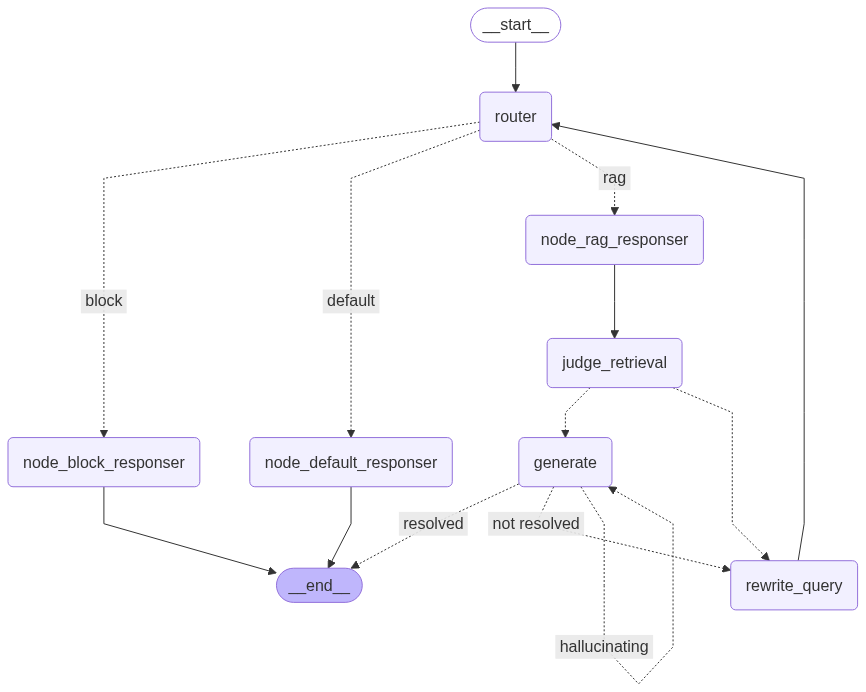

In [ ]:
#----5. 그래프 생성 및 컴파일----
from langgraph.prebuilt import ToolNode, tools_condition
from langgraph.checkpoint.memory import MemorySaver

#메모리 저장
memory = MemorySaver()

#build graph
graph = (
    StateGraph(State)
    
    #node
    .add_node("router", router)
    .add_node("node_rag_responser", node_rag_responser)
    .add_node("node_default_responser", node_default_responser)
    .add_node("node_block_responser", node_block_responser)
    .add_node("generate", generate)
    .add_node("judge_retrieval", judge_retrieval)
    .add_node("rewrite_query", rewrite_query)
    
    #edge
    .add_edge(START, "router")
    
    #조건부 edge
    .add_conditional_edges(
        "router",
        route_query,
        {
            "rag": "node_rag_responser",
            "default": "node_default_responser",
            "block": "node_block_responser",
        }
    )
    .add_edge("node_default_responser", END)
    .add_edge("node_rag_responser", "judge_retrieval")
    .add_conditional_edges(
        "judge_retrieval",
        generate_or_rewrite_query,
        {
            "generate": "generate",
            "rewrite_query": "rewrite_query"
        }
    )
    .add_edge("rewrite_query", "router")
    .add_conditional_edges(
        "generate",
        judge_factfullness,
        {
            "hallucinating": "generate",
            "resolved": END,
            "not resolved": "rewrite_query"
        }
    )

    #compile
    .compile(checkpointer=memory)
)

#그래프 시각화
from IPython.display import display, Image

diagram = Image(
    graph.get_graph().draw_mermaid_png()
)
display(diagram)

In [ ]:
#----6. Test----
import uuid
from langgraph.errors import GraphRecursionError
from langchain_core.runnables import RunnableConfig

config = RunnableConfig(recuesion_limit = 10)

def run(input_msg):
    def clean(text):
        return text.replace("\n", "")[:50] + "..."
    
    # 유저 확인: 각 대화마다 고유한 thread_id를 생성하거나 지정
    config = RunnableConfig(
        configurable={"thread_id": str(uuid.uuid4())},
    )
    
    inputs = {
        "input_msg": input_msg
    }
    
    try:
        for output in graph.stream(inputs, config):
            for key, value in output.items():
                if "input_msg" in value:
                    print(f"     input_msg    : {value['input_msg']}")
                if "documents" in value:
                    for idx, doc in enumerate(value['documents']):
                        print(f"     document    : {clean(doc.page_content)}")
                if "generation" in value:
                    print(f"     generation     : {value['generation']}")
                if "source" in value:
                    print(f"     source     : {value['source']}")
        print("\n")    
        print("Generation: ", value["generation"])
        print("="*100, "\n") 
        
    except GraphRecursionError:
        print("\n---\n")
        print("I coudn't find the answer to your question...")

In [ ]:
#실행~!
inputs = [
    "오늘 날씨는 어때?",
    "예수님은 누구신가요?",
    "이 곳에서 나가" 
]

for msg in inputs:
    run(msg)

2025-07-26 23:00:50,212 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


>> ROUTE QUESTION TO DEFAULT
     input_msg    : 오늘 날씨는 어때?
>> DEFAULT


2025-07-26 23:00:51,616 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


     input_msg    : 오늘 날씨는 어때?
     generation     : Hello! I'm here to listen and support you with compassion and understanding. How can I assist you today? Whether you have questions, need someone to talk to, or are seeking guidance, I'm here for you.
     source     : default


Generation:  Hello! I'm here to listen and support you with compassion and understanding. How can I assist you today? Whether you have questions, need someone to talk to, or are seeking guidance, I'm here for you.



2025-07-26 23:00:52,173 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


...

2025-07-26 23:01:01,558 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


     >> DECISION: YES
     input_msg    : 예수님은 누구신가요?
     document    : 질문: 예수님께서 자신이 하나님이라는 것을 언제 아셨을까요?답변: 예수님은 언제나 하나님이...
     document    : 질문: 실제 역사상의 예수님은 어떤 분이었나요?답변: 의심할 것 없이 “예수는 누구였나?”...
     document    : 질문: 예수님의 인성이 중요한 이유는 무엇입니까?답변: 예수님의 인성은 예수님의 신성만큼이...
     document    : 질문: 위격의 연합이란 무엇인가?답변: 위격적 연합(hypostatic union)은 성자...
     generation     : 예수님은 기독교의 중심 인물로, 하나님의 아들이자 인류의 구세주입니다. 그는 우리의 죄를 위해 십자가에서 죽으시고, 부활하심으로써 영원한 생명을 주셨습니다. 요한복음 3장 16절에서 "하나님이 세상을 이처럼 사랑하사 독생자를 주셨으니"라고 말씀하신 것처럼, 예수님은 하나님의 사랑의 표현이죠.
     source     : vectorstore


Generation:  예수님은 기독교의 중심 인물로, 하나님의 아들이자 인류의 구세주입니다. 그는 우리의 죄를 위해 십자가에서 죽으시고, 부활하심으로써 영원한 생명을 주셨습니다. 요한복음 3장 16절에서 "하나님이 세상을 이처럼 사랑하사 독생자를 주셨으니"라고 말씀하신 것처럼, 예수님은 하나님의 사랑의 표현이죠.



2025-07-26 23:01:02,191 - httpx - INFO - HTTP Request: POST https://api.openai.com/v1/chat/completions "HTTP/1.1 200 OK"


>> ROUTE QUESTION TO BLOCK
     input_msg    : 이 곳에서 나가
>> BLOCK


TypeError: argument of type 'NoneType' is not iterable

In [ ]:
######아직 구현 못한거#######

# log 저장 및 DB 연결
# 챗 ID 적용 안 됨